This notebook is about HDBScan.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df=pd.read_csv("urban_pedestrian_locations_with_labels.csv")
df.head()

,x_position,y_position,true_cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   x_position    500 non-null    float64
 1   y_position    500 non-null    float64
 2   true_cluster  500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [15]:
df.describe()

,x_position,y_position,true_cluster
count,500.000000,500.000000,500.000000
mean,0.504536,0.251342,0.500000
std,0.870047,0.498529,0.500501
min,-1.079039,-0.605083,0.000000
25%,-0.030705,-0.223623,0.000000
50%,0.484762,0.265299,0.500000
75%,1.039928,0.699438,1.000000
max,2.083614,1.111774,1.000000


In [16]:
df.columns

Index(['x_position', 'y_position', 'true_cluster'], dtype='object')

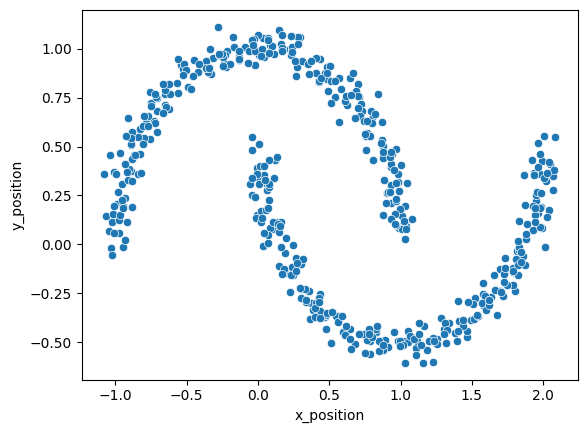

In [17]:
sns.scatterplot(data=df,x="x_position",y="y_position")
plt.show()

In [18]:
df=df.drop("true_cluster", axis=1)
df.head()

,x_position,y_position
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [19]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)

In [20]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN()
dbscan.fit(X_scaled)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.5
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [21]:
dbscan.labels_

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

In [22]:
X_scaled = pd.DataFrame(X_scaled, columns = ["x_position", "y_position"])

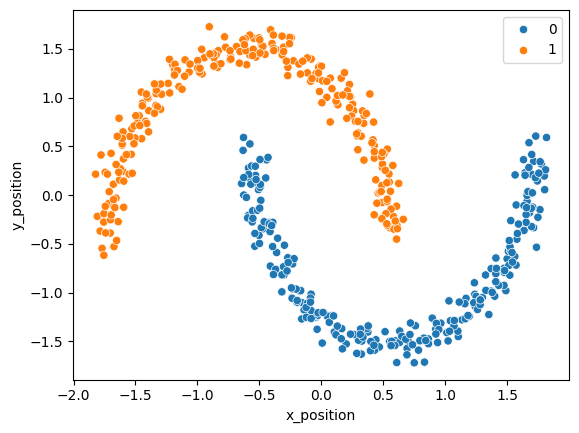

In [23]:
sns.scatterplot(data=X_scaled, x="x_position", y="y_position", hue=dbscan.labels_)
plt.show()

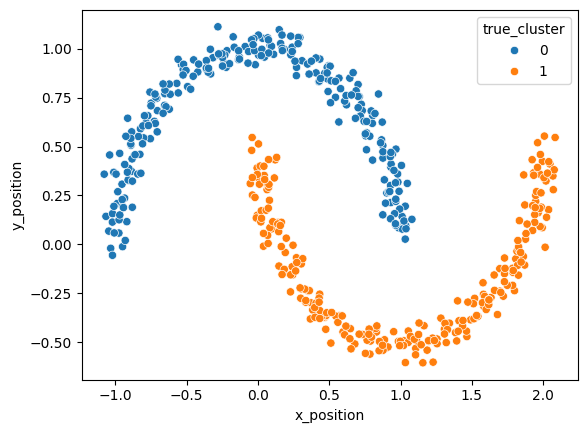

In [24]:
df = pd.read_csv("urban_pedestrian_locations_with_labels.csv")
df.columns
sns.scatterplot(data=df, x="x_position", y="y_position", hue="true_cluster")
plt.show()

In [25]:
#Hyperparameter grids
eps_values = [0.1,0.2,0.3,0.4,0.5,0.6]
min_samples_values = [4,5,6]

In [26]:
from sklearn.metrics import silhouette_score

#Store results
results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
        labels = db.labels_
        #Skip if all points are noise or only one cluster found
        if len(set(labels)) <= 1:
            continue
        
        silhouette = silhouette_score(X_scaled, labels)
        
        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'Silhouette': silhouette,
            'n_clusters': len(set(labels)) - (1 if -1 in labels else 0)
        })

#Convert to DataFrame and sort by silhouette 
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Silhouette', ascending=False)

In [27]:
results_df

,eps,min_samples,Silhouette,n_clusters
4,0.2,5,0.389338,2
3,0.2,4,0.389338,2
14,0.5,6,0.389338,2
11,0.4,6,0.389338,2
5,0.2,6,0.389338,2
6,0.3,4,0.389338,2
8,0.3,6,0.389338,2
7,0.3,5,0.389338,2
9,0.4,4,0.389338,2
10,0.4,5,0.389338,2


c:\Users\sudet\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


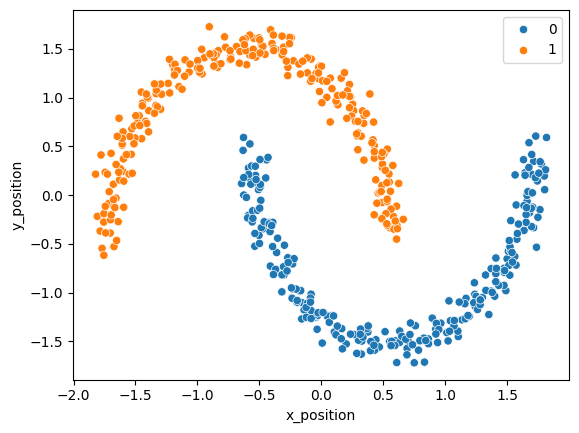

In [28]:
from sklearn.cluster import HDBSCAN
hdbscan = HDBSCAN()
hdbscan.fit(X_scaled)
hdbscan.labels_
sns.scatterplot(data=X_scaled, x="x_position", y="y_position", hue=hdbscan.labels_)
plt.show()

In [29]:
min_cluster_sizes = [3, 5, 7, 10]
min_samples = [None, 3, 5, 7]

In [ ]:
results = []

for min_cluster in min_cluster_sizes:
    for min_sample in min_samples:
        hdb = HDBSCAN(min_cluster_size=min_cluster, min_samples=min_sample).fit(X_scaled)
        labels = hdb.labels_
        # Skip if all points are noise or only one cluster found
        if len(set(labels)) <= 1:
            continue
        
        silhouette = silhouette_score(X_scaled, labels)
        
        results.append({
            'min_cluster_size': min_cluster,
            'min_samples': min_sample,
            'Silhouette': silhouette,
            'n_clusters': len(set(labels)) - (1 if -1 in labels else 0)
        })

# Convert to DataFrame and sort by silhouette 
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Silhouette', ascending=False)

In [31]:
results_df

,min_cluster_size,min_samples,Silhouette,n_clusters
3,3,7.0,0.389338,2
2,3,5.0,0.389338,2
5,5,3.0,0.389338,2
4,5,NaN,0.389338,2
6,5,5.0,0.389338,2
7,5,7.0,0.389338,2
9,7,3.0,0.389338,2
8,7,NaN,0.389338,2
12,10,NaN,0.389338,2
13,10,3.0,0.389338,2
